In [2]:
import random
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import pathlib
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import sampler

In [3]:
from utils import *

In [21]:
data_dir = 'data'

mnist_train = datasets.MNIST(data_dir, train=True, transform=transforms.ToTensor(),download=True)
mnist_test = datasets.MNIST(data_dir, train=False, transform=transforms.ToTensor(),download=True)

In [29]:
train_set, val_set = torch.utils.data.random_split(mnist_train, [54000, 6000], generator=torch.Generator().manual_seed(1))

In [31]:
print(len(train_set), len(val_set))

54000 6000


In [7]:
loss_function = nn.CrossEntropyLoss()

In [51]:
from torch.nn.modules.flatten import Flatten
# TODO define model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        modules = [nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, stride = 1),
                   nn.MaxPool2d(kernel_size=2),
                   # default stride = kernel_size
                   nn.ReLU(),
                   nn.Flatten(),
                   nn.Linear(12*12*32, 512),
                   nn.ReLU(),
                   nn.Linear(512, 10)]
        self.model = torch.nn.Sequential(*modules)
    
    def forward(self, x):
        return self.model(x)

In [52]:
batch_size = 256

In [49]:
# TODO create dataloader for training, validation and test
train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

cuda available: False ; cudnn available: False ; num devices: 0
Using device cpu


Finished training after 580 seconds.


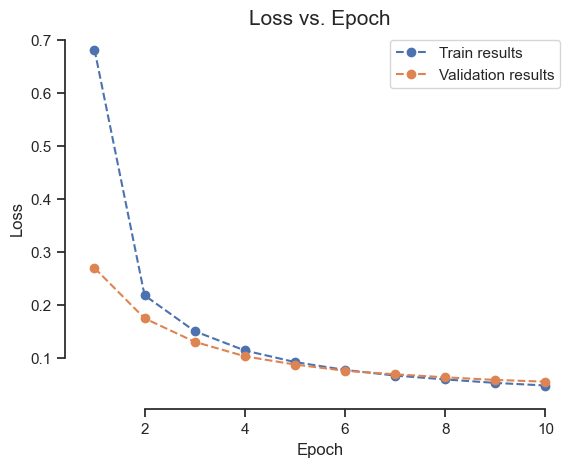

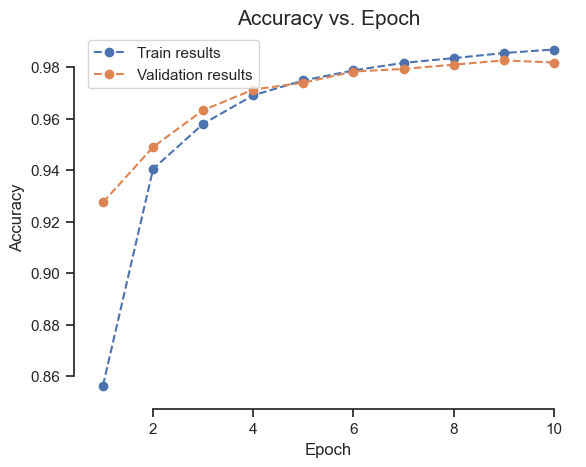

In [55]:
# TODO train and plot
device = get_device()
lr = 0.0001
model = CNN()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

model.train()
train_losses, val_losses, train_accs, val_accs, confusion_matrix = run_training(model, optimizer, loss_function, device, 10, train_dataloader, val_dataloader)
plot('Loss vs. Epoch', 'Loss' ,train_losses, val_losses)
plot('Accuracy vs. Epoch', 'Accuracy' ,train_accs, val_accs)